**Subquestion 3:** to what extent does the distance to the nearest reference
stations change inference performance?

The experiment thins the reference network around every held out station for each radius R in 0, 15, 35 and 60 km
and for each held out station:


## 1. Settings and paths

In [ ]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from scipy.stats import wilcoxon

# imputed station CSVs and the station coordinates location
DATA_DIR = r"C:\Users\Storm Anderson\Documents\UVA\Inferencing\XGboost\data_imputed"
COORDS_CSV = r"C:\Users\Storm Anderson\Documents\UVA\Inferencing\XGboost\station_cell_map.csv"

# outputs 
OUT_TABLES = os.path.join("results", "tables")
OUT_FIGURES = os.path.join("results", "figures")
os.makedirs(OUT_TABLES, exist_ok=True)
os.makedirs(OUT_FIGURES, exist_ok=True)

# time split
TRAIN_YEAR_MAX = 2022   
VAL_YEAR = 2023         
TEST_YEAR = 2024        

USE_GPU = True          # set to False on a pc without an NVIDIA GPU

# Optuna tuned hyperparameters
PARAMS = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "max_depth": 5,
    "learning_rate": 0.050174637405817,
    "min_child_weight": 11,
    "subsample": 0.5982185916706947,
    "colsample_bytree": 0.7254529566891234,
    "reg_lambda": 0.5349747167608838,
    "reg_alpha": 3.625170550327679,
    "gamma": 1.605431841969294,
    "tree_method": "hist",
    "seed": 42,
    "device": "cuda" if USE_GPU else "cpu",
}
N_ROUNDS = 2000     # maximum number of boosting rounds
EARLY_STOP = 50     # early stopping patience on the 2023 validation year

K_NEAREST = 5       # neighbors used for nb_1 to nb_5, idw_neighbor and the wind cones
K_QUAD = 8          # neighbors used for the quadratic surface fit
IDW_POWER = 2.0     # inverse distance weighting power
LAG_HOURS = [1, 3, 6, 24]

pd.set_option("display.max_columns", None)
print("device:", PARAMS["device"])

device: cuda


In [2]:
# the exclusion radius
RADII = [0, 15, 35, 60]
print("radii:", RADII, "km")

radii: [0, 15, 35, 60] km


## 2. Feature groups (69 features in six groups)

In [ ]:
# the six feature groups, using the column names of the station CSVs
NETWORK_FEATURES = [
    "nb_1", "nb_2", "nb_3", "nb_4", "nb_5",
    "idw_neighbor",
    "nb1_lag_1h", "nb1_lag_3h", "nb1_lag_6h", "nb1_lag_24h",
    "nb1_24h_mean", "nb1_24h_std",
    "pm_upwind", "pm_downwind", "n_upwind", "n_downwind",
    "pm_gradient", "pm_advection", "pm_diffusion",
    "pm_upwind_isna", "pm_downwind_isna",
]

LCS_FEATURES = ["lcs_adv", "lcs_adv_coef", "f_rh", "lcs_x_frh", "lcs_rh_corrected"]

ERA5_FEATURES = [
    "t2m", "rh", "wind_speed", "wind_dir_sin", "wind_dir_cos",
    "sp", "ssr", "strd", "tp", "slhf", "sshf",
    "blh", "low_blh", "ventilation_coef", "stagnant", "stagnation_hours",
]

EAC4_FEATURES = [
    "aod550", "bcaod550", "duaod550", "ssaod550", "gtco3", "pm2p5",
    "co_1000hPa", "go3_1000hPa", "no2_1000hPa", "so2_1000hPa",
    "co_700hPa", "go3_700hPa", "no2_700hPa", "so2_700hPa",
    "co_500hPa", "go3_500hPa", "no2_500hPa", "so2_500hPa",
]

GEO_FEATURES = ["lat", "lon"]

TIME_FEATURES = ["hour_sin", "hour_cos", "doy_sin", "doy_cos", "dow_sin", "dow_cos", "year"]

ALL_FEATURES = (NETWORK_FEATURES + LCS_FEATURES + ERA5_FEATURES
                + EAC4_FEATURES + GEO_FEATURES + TIME_FEATURES)

print("features per group: network", len(NETWORK_FEATURES), "| lcs", len(LCS_FEATURES),
      "| era5", len(ERA5_FEATURES), "| eac4", len(EAC4_FEATURES),
      "| geo", len(GEO_FEATURES), "| time", len(TIME_FEATURES))
print("total features:", len(ALL_FEATURES))

# columns every fold table keeps next to the features
# lcs_median_pm25 is only used by the raw model in the ablation notebook
# the loop avoids duplicate columns, year is both an id column and a time feature
KEEP_COLS = ["station_id", "datetime", "year", "month", "ref_pm25", "lcs_median_pm25"]
for col in ALL_FEATURES:
    if col not in KEEP_COLS:
        KEEP_COLS.append(col)
print("columns per fold table:", len(KEEP_COLS))

features per group: network 21 | lcs 5 | era5 16 | eac4 18 | geo 2 | time 7
total features: 69
columns per fold table: 74


## 3. Load the data

In [ ]:
t0 = time.time()
station_folders = sorted(os.listdir(DATA_DIR))

stations = {}
for folder in station_folders:
    folder_path = os.path.join(DATA_DIR, folder)
    if not os.path.isdir(folder_path):
        continue  # skips loose files like imputation_report.csv
    df = pd.read_csv(os.path.join(folder_path, folder + ".csv"))
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.sort_values("datetime").reset_index(drop=True)
    df["station_id"] = folder
    stations[folder] = df

STATION_IDS = list(stations.keys())

# station coordinates, also used as the geo features lat and lon
coords = pd.read_csv(COORDS_CSV)
coords = coords[coords["station_id"].isin(STATION_IDS)].set_index("station_id")[["lat", "lon"]]

for name in STATION_IDS:
    stations[name]["lat"] = coords.loc[name, "lat"]
    stations[name]["lon"] = coords.loc[name, "lon"]

# panel of the imputed reference PM2.5: rows are hours, columns are stations
# every neighbor feature below reads from this panel
panel = pd.DataFrame()
for name in STATION_IDS:
    df = stations[name]
    panel[name] = pd.Series(df["ref_pm25"].values, index=df["datetime"])
panel = panel.sort_index()

print("stations:", len(stations), "| panel shape:", panel.shape,
      "| loaded in", round(time.time() - t0, 1), "s")

stations: 31 | panel shape: (35064, 31) | loaded in 14.6 s


## 4. Helper functions

Geometry, rebuild of the neighbor features, the fold builder, the
train function and the metric functions. These cells are identical in notebooks 01 to 04

In [ ]:
def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0
    p1 = np.radians(lat1)
    p2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlam / 2.0) ** 2
    return 2.0 * R * np.arcsin(np.sqrt(a))


def bearing_rad(lat1, lon1, lat2, lon2):
    # compass bearing from point 1 to point 2, in radians from north, clockwise
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dlon = np.radians(lon2 - lon1)
    x = np.sin(dlon) * np.cos(phi2)
    y = np.cos(phi1) * np.sin(phi2) - np.sin(phi1) * np.cos(phi2) * np.cos(dlon)
    return np.mod(np.arctan2(x, y), 2.0 * np.pi)


def angle_diff(a, b):
    # shortest signed angle a minus b, in [-pi, pi]
    return np.mod(a - b + np.pi, 2.0 * np.pi) - np.pi


def nearest_neighbors(target_id, available_ids, k):
    # the k nearest stations to target_id, chosen only from available_ids, never itself
    lat0 = coords.loc[target_id, "lat"]
    lon0 = coords.loc[target_id, "lon"]
    rows = []
    for other in available_ids:
        if other == target_id:
            continue
        lat1 = coords.loc[other, "lat"]
        lon1 = coords.loc[other, "lon"]
        rows.append({
            "id": other,
            "lat": lat1,
            "lon": lon1,
            "dist_km": float(haversine_km(lon0, lat0, lon1, lat1)),
            "bearing_rad": float(bearing_rad(lat0, lon0, lat1, lon1)),
        })
    rows.sort(key=lambda r: r["dist_km"])
    return rows[:k]

In [ ]:
def rebuild_network_features(station_id, df_station, available_ids):
    # Returns a copy of the station table in which every neighbor derived feature is recomputed from only the stations 
    # in available_ids. This is the leakage control. The held out station (and any station removed by a distance band) is not in
    # available_ids, so its measurements cannot reach any feature in this fold. The formulas are same in to the feature 
    # engineering notebook. Values that cannot be computed stay NaN, XGBoost handles NaN natively.
    df = df_station.copy()
    n = len(df)
    meta5 = nearest_neighbors(station_id, available_ids, K_NEAREST)
    meta8 = nearest_neighbors(station_id, available_ids, K_QUAD)

    # neighbor readings nb_1 to nb_5
    for i in range(K_NEAREST):
        if i < len(meta5):
            df["nb_" + str(i + 1)] = panel[meta5[i]["id"]].reindex(df["datetime"]).values
        else:
            df["nb_" + str(i + 1)] = np.nan

    # inverse distance weighted mean of the neighbor readings
    num = np.zeros(n)
    den = np.zeros(n)
    for i in range(len(meta5)):
        d = max(meta5[i]["dist_km"], 0.1)
        w = 1.0 / d ** IDW_POWER
        vals = df["nb_" + str(i + 1)].values
        ok = ~np.isnan(vals)
        num = num + np.where(ok, vals * w, 0.0)
        den = den + np.where(ok, w, 0.0)
    with np.errstate(invalid="ignore", divide="ignore"):
        df["idw_neighbor"] = np.where(den > 0, num / den, np.nan)

    # lagged block from the nearest neighbor (left closed, so no future values)
    if len(meta5) > 0:
        nb1 = panel[meta5[0]["id"]]
        for h in LAG_HOURS:
            df["nb1_lag_" + str(h) + "h"] = nb1.reindex(df["datetime"] - pd.Timedelta(hours=h)).values
        roll_mean = nb1.rolling("24h", closed="left", min_periods=12).mean()
        roll_std = nb1.rolling("24h", closed="left", min_periods=12).std()
        df["nb1_24h_mean"] = roll_mean.reindex(df["datetime"]).values
        df["nb1_24h_std"] = roll_std.reindex(df["datetime"]).values
    else:
        for h in LAG_HOURS:
            df["nb1_lag_" + str(h) + "h"] = np.nan
        df["nb1_24h_mean"] = np.nan
        df["nb1_24h_std"] = np.nan

    # upwind and downwind neighbor averages (120 degree cones)
    cone_half_rad = np.radians(60.0)
    theta_to = np.mod(np.arctan2(df["u10"].values, df["v10"].values), 2.0 * np.pi)
    theta_from = np.mod(theta_to + np.pi, 2.0 * np.pi)
    up_num = np.zeros(n)
    up_den = np.zeros(n)
    up_count = np.zeros(n, dtype=int)
    dn_num = np.zeros(n)
    dn_den = np.zeros(n)
    dn_count = np.zeros(n, dtype=int)
    for i in range(len(meta5)):
        pm = df["nb_" + str(i + 1)].values
        valid = ~np.isnan(pm)
        w = 1.0 / max(meta5[i]["dist_km"], 0.1)
        beta = meta5[i]["bearing_rad"]
        in_up = (np.abs(angle_diff(beta, theta_from)) <= cone_half_rad) & valid
        in_dn = (np.abs(angle_diff(beta, theta_to)) <= cone_half_rad) & valid
        up_num = up_num + np.where(in_up, pm * w, 0.0)
        up_den = up_den + np.where(in_up, w, 0.0)
        up_count = up_count + in_up.astype(int)
        dn_num = dn_num + np.where(in_dn, pm * w, 0.0)
        dn_den = dn_den + np.where(in_dn, w, 0.0)
        dn_count = dn_count + in_dn.astype(int)
    with np.errstate(invalid="ignore", divide="ignore"):
        df["pm_upwind"] = np.where(up_den > 0, up_num / up_den, np.nan)
        df["pm_downwind"] = np.where(dn_den > 0, dn_num / dn_den, np.nan)
    df["n_upwind"] = up_count
    df["n_downwind"] = dn_count

    # convection diffusion terms from a quadratic surface fit on the 8 nearest
    if len(meta8) > 0:
        lat0 = coords.loc[station_id, "lat"]
        lon0 = coords.loc[station_id, "lon"]
        A = np.zeros((len(meta8), 6))
        for i in range(len(meta8)):
            dx = (meta8[i]["lon"] - lon0) * 111.32 * np.cos(np.radians(lat0))
            dy = (meta8[i]["lat"] - lat0) * 110.57
            A[i, 0] = 1.0
            A[i, 1] = dx
            A[i, 2] = dy
            A[i, 3] = dx * dx
            A[i, 4] = dy * dy
            A[i, 5] = dx * dy
        A_pinv = np.linalg.pinv(A)
        values = np.zeros((n, len(meta8)))
        for i in range(len(meta8)):
            values[:, i] = panel[meta8[i]["id"]].reindex(df["datetime"]).values
        coef = values @ A_pinv.T
        bad = np.isnan(values).any(axis=1)
        coef[bad, :] = np.nan
        grad_x = coef[:, 1]
        grad_y = coef[:, 2]
        df["pm_gradient"] = np.sqrt(grad_x ** 2 + grad_y ** 2)
        df["pm_advection"] = -(df["u10"].values * grad_x + df["v10"].values * grad_y) * 3.6
        df["pm_diffusion"] = 2.0 * coef[:, 3] + 2.0 * coef[:, 4]
    else:
        df["pm_gradient"] = np.nan
        df["pm_advection"] = np.nan
        df["pm_diffusion"] = np.nan

    # missing indicators for the two cone features
    df["pm_upwind_isna"] = df["pm_upwind"].isna().astype(int)
    df["pm_downwind_isna"] = df["pm_downwind"].isna().astype(int)
    return df

In [ ]:
def build_fold_table(held_out, radius_km):
    # Builds the data for one LOSO fold. The held out station never appears in the training set and is never 
    # a candidate. For the distance bands every station within radius_km of the held out station is removed from the fold
    # completely: its rows leave the training set and it stops being a candidate for everyone. All remaining 
    # stations get rebuilt neighbor features, so nothing from the held out or removed stations can leak in.
    lat0 = coords.loc[held_out, "lat"]
    lon0 = coords.loc[held_out, "lon"]

    removed = []
    for other in STATION_IDS:
        if other == held_out:
            continue
        d = float(haversine_km(lon0, lat0, coords.loc[other, "lon"], coords.loc[other, "lat"]))
        if radius_km > 0 and d <= radius_km:
            removed.append(other)

    available = []
    for s in STATION_IDS:
        if s != held_out and s not in removed:
            available.append(s)

    # with the real 31 station network at least 5 stations always remain, even at 60 km
    if len(available) == 0:
        raise ValueError("radius " + str(radius_km) + " km removes every station around " + held_out)

    # training set (pool): every available station with rebuilt neighbor features
    pool_parts = []
    for s in available:
        rebuilt = rebuild_network_features(s, stations[s], available)
        pool_parts.append(rebuilt[KEEP_COLS])
    pool = pd.concat(pool_parts, ignore_index=True)

    # held out test rows: features rebuilt from the available network only
    test = rebuild_network_features(held_out, stations[held_out], available)
    test = test[test["year"] == TEST_YEAR]
    test = test[KEEP_COLS].reset_index(drop=True)

    return pool, test, removed

In [ ]:
def train_one_fold(pool, test, feature_list):
    # Train on 2021 to 2022, find the number of rounds with early stopping on 2023,
    # refit on 2021 to 2023 with that number of rounds, then predict the 2024 test rows. 
    train = pool[pool["year"] <= TRAIN_YEAR_MAX]
    val = pool[pool["year"] == VAL_YEAR]
    refit = pool[pool["year"] <= VAL_YEAR]

    dtrain = xgb.DMatrix(train[feature_list], label=train["ref_pm25"])
    dval = xgb.DMatrix(val[feature_list], label=val["ref_pm25"])
    booster = xgb.train(PARAMS, dtrain, num_boost_round=N_ROUNDS,
                        evals=[(dval, "val")], early_stopping_rounds=EARLY_STOP,
                        verbose_eval=False)
    best_rounds = booster.best_iteration + 1

    drefit = xgb.DMatrix(refit[feature_list], label=refit["ref_pm25"])
    final = xgb.train(PARAMS, drefit, num_boost_round=best_rounds, verbose_eval=False)

    y_pred = final.predict(xgb.DMatrix(test[feature_list]))
    return y_pred, best_rounds

In [ ]:
def compute_metrics(y_true, y_pred):
    # RMSE, MAE and R2 on the rows where both values exist
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ok = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true = y_true[ok]
    y_pred = y_pred[ok]
    if len(y_true) == 0:
        return {"n_hours": 0, "RMSE": np.nan, "MAE": np.nan, "R2": np.nan}
    err = y_pred - y_true
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    if ss_tot > 0:
        r2 = 1.0 - ss_res / ss_tot
    else:
        r2 = np.nan
    return {"n_hours": int(len(y_true)), "RMSE": rmse, "MAE": mae, "R2": r2}


def hourly_metrics_table(pred_df):
    # RMSE, MAE and R2 across the held out stations, for every evaluated hour
    rows = []
    for dt_value, group in pred_df.groupby("datetime"):
        m = compute_metrics(group["y_true"], group["y_pred"])
        rows.append({"datetime": dt_value, "n_stations": m["n_hours"],
                     "RMSE": m["RMSE"], "MAE": m["MAE"], "R2": m["R2"]})
    out = pd.DataFrame(rows).sort_values("datetime").reset_index(drop=True)
    return out


def bh_correction(p_values):
    # BH correction
    p = pd.Series(p_values, dtype=float)
    m = p.notna().sum()
    q = (p * m / p.rank(method="first")).clip(upper=1.0)
    return q

## 5. Run the distance band experiment

One new model per station per radius

In [11]:
per_station_tables = {}

t0 = time.time()
for radius in RADII:
    print("== radius", radius, "km ==")
    per_rows = []
    pred_parts = []

    for k, held_out in enumerate(STATION_IDS):
        pool, test, removed = build_fold_table(held_out, radius_km=radius)
        y_pred, best_rounds = train_one_fold(pool, test, ALL_FEATURES)

        preds = test[["station_id", "datetime", "ref_pm25"]].copy()
        preds = preds.rename(columns={"ref_pm25": "y_true"})
        preds["y_pred"] = y_pred
        pred_parts.append(preds)

        m = compute_metrics(preds["y_true"], preds["y_pred"])
        m["station_id"] = held_out
        m["radius_km"] = radius
        m["n_removed"] = len(removed)
        m["n_available"] = len(STATION_IDS) - 1 - len(removed)
        m["best_rounds"] = best_rounds
        per_rows.append(m)

        minutes = (time.time() - t0) / 60.0
        print("  [%2d/%d] %s: RMSE %.3f | removed %2d | %.1f min"
              % (k + 1, len(STATION_IDS), held_out, m["RMSE"], len(removed), minutes))

    per_station = pd.DataFrame(per_rows)
    per_station = per_station[["station_id", "radius_km", "n_removed", "n_available",
                               "n_hours", "RMSE", "MAE", "R2", "best_rounds"]]
    per_station_tables[radius] = per_station

    predictions = pd.concat(pred_parts, ignore_index=True)

    tag = "sq3_r" + str(radius) + "km"
    per_station.round(4).to_csv(os.path.join(OUT_TABLES, tag + "_per_station_metrics.csv"), index=False)
    predictions.to_csv(os.path.join(OUT_TABLES, tag + "_predictions.csv"), index=False, float_format="%.4f")
    hourly = hourly_metrics_table(predictions)
    hourly.to_csv(os.path.join(OUT_TABLES, tag + "_hourly_metrics.csv"), index=False, float_format="%.4f")

    print("  saved", tag, "| mean station RMSE %.3f" % per_station["RMSE"].mean())
    print()

== radius 0 km ==
  [ 1/31] NL01485_PM2.5_lucht: RMSE 3.449 | removed  0 | 0.3 min
  [ 2/31] NL01487_PM2.5_lucht: RMSE 2.798 | removed  0 | 0.5 min
  [ 3/31] NL01488_PM2.5_lucht: RMSE 1.640 | removed  0 | 0.7 min
  [ 4/31] NL01489_PM2.5_lucht: RMSE 1.479 | removed  0 | 0.9 min
  [ 5/31] NL01491_PM2.5_lucht: RMSE 1.872 | removed  0 | 1.1 min
  [ 6/31] NL01494_PM2.5_lucht: RMSE 2.336 | removed  0 | 1.3 min
  [ 7/31] NL01496_PM2.5_lucht: RMSE 3.908 | removed  0 | 1.6 min
  [ 8/31] NL01912_PM2.5_lucht: RMSE 1.660 | removed  0 | 1.8 min
  [ 9/31] NL10136_PM2.5_lucht: RMSE 5.871 | removed  0 | 1.9 min
  [10/31] NL10418_PM2.5_lucht: RMSE 3.491 | removed  0 | 2.2 min
  [11/31] NL10449_PM2.5_lucht: RMSE 7.621 | removed  0 | 2.4 min
  [12/31] NL10636_PM2.5_lucht: RMSE 3.394 | removed  0 | 2.6 min
  [13/31] NL10643_PM2.5_lucht: RMSE 4.301 | removed  0 | 2.9 min
  [14/31] NL10738_PM2.5_lucht: RMSE 3.934 | removed  0 | 3.0 min
  [15/31] NL10741_PM2.5_lucht: RMSE 5.186 | removed  0 | 3.3 min
  [16/3

## 6. Summary per radius

Mean and median over the 31 held out stations

In [ ]:
rows = []
for radius in RADII:
    ps = per_station_tables[radius]
    rows.append({
        "radius_km": radius,
        "mean_RMSE": ps["RMSE"].mean(),
        "median_RMSE": ps["RMSE"].median(),
        "mean_MAE": ps["MAE"].mean(),
        "mean_R2": ps["R2"].mean(),
        "median_R2": ps["R2"].median(),
        "mean_n_removed": ps["n_removed"].mean(),
        "min_n_available": int(ps["n_available"].min()),
    })
summary = pd.DataFrame(rows)
summary.round(4).to_csv(os.path.join(OUT_TABLES, "sq3_summary.csv"), index=False)
print(summary.round(3).to_string(index=False))

base_rmse = float(summary.loc[summary["radius_km"] == 0, "mean_RMSE"].iloc[0])
base_r2 = float(summary.loc[summary["radius_km"] == 0, "mean_R2"].iloc[0])
worst_rmse = float(summary.loc[summary["radius_km"] == max(RADII), "mean_RMSE"].iloc[0])
worst_r2 = float(summary.loc[summary["radius_km"] == max(RADII), "mean_R2"].iloc[0])
print()
print("RMSE change 0 to %d km: %+.1f%%" % (max(RADII), 100.0 * (worst_rmse - base_rmse) / base_rmse))
print("R2 change 0 to %d km: %+.1f%%" % (max(RADII), 100.0 * (worst_r2 - base_r2) / base_r2))

XGBoost
 radius_km  mean_RMSE  median_RMSE  mean_MAE  mean_R2  median_R2  mean_n_removed  min_n_available
         0       3.63         3.80     2.595    0.705      0.730           0.000               30
        15       4.15         4.02     3.087    0.630      0.660           4.452               22
        35       4.62         4.20     3.376    0.555      0.610           7.742               17
        60       5.12         4.93     3.652    0.455      0.505          12.194                5

RMSE change 0 to 60 km: +41.0%
R2 change 0 to 60 km: -35.5%


## 7. Wilcoxon tests versus the intact network

Paired Wilcoxon signed rank test of every radius against 0 km on the per  RMSE, with a BH correction over the three tests.

In [ ]:
base = per_station_tables[0][["station_id", "RMSE"]].rename(columns={"RMSE": "RMSE_0km"})

rows = []
for radius in RADII:
    if radius == 0:
        continue
    cur = per_station_tables[radius][["station_id", "RMSE"]]
    merged = base.merge(cur, on="station_id")
    diff = (merged["RMSE"] - merged["RMSE_0km"]).values
    nonzero = diff[diff != 0]
    if len(nonzero) >= 3:
        p = float(wilcoxon(nonzero).pvalue)
    else:
        p = np.nan
    rows.append({"radius_km": radius,
                 "n_stations": len(diff),
                 "n_worse_than_0km": int((diff > 0).sum()),
                 "median_dRMSE_vs_0km": float(np.median(diff)),
                 "p": p})

wil = pd.DataFrame(rows)
wil["q_BH"] = bh_correction(wil["p"])
wil["significant"] = wil["q_BH"] < 0.05
wil.round(6).to_csv(os.path.join(OUT_TABLES, "sq3_wilcoxon_vs_0km.csv"), index=False)

## 8. Network thinning figures 

Mean (solid) and median (dashed) over the 31 stations against the exclusion radius. 

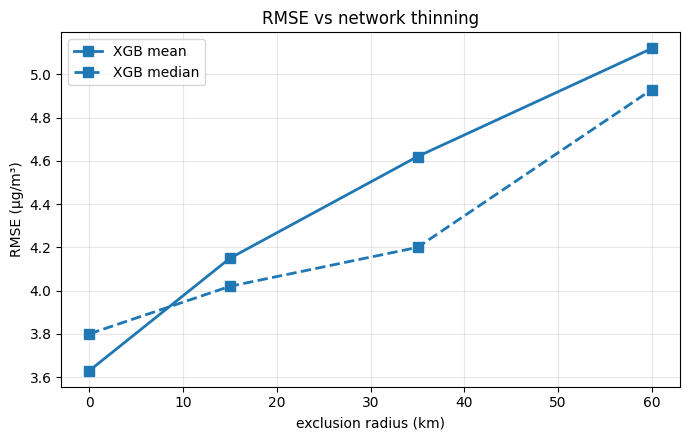

saved: figures\sq3_rmse_vs_radius.png


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(summary["radius_km"], summary["mean_RMSE"], marker="s", markersize=7,
        color="tab:blue", linewidth=2, label="XGB mean")
ax.plot(summary["radius_km"], summary["median_RMSE"], marker="s", markersize=7,
        color="tab:blue", linewidth=2, linestyle="--", label="XGB median")
ax.set_xlabel("exclusion radius (km)")
ax.set_ylabel("RMSE (µg/m³)")
ax.set_title("RMSE vs network thinning")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_FIGURES, "sq3_rmse_vs_radius.png"), dpi=200, bbox_inches="tight")
plt.show()
print("saved:", os.path.join(OUT_FIGURES, "sq3_rmse_vs_radius.png"))

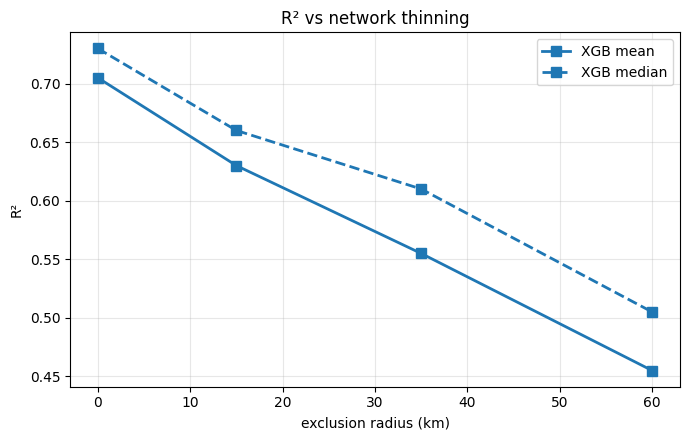

saved: figures\sq3_r2_vs_radius.png


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(summary["radius_km"], summary["mean_R2"], marker="s", markersize=7,
        color="tab:blue", linewidth=2, label="XGB mean")
ax.plot(summary["radius_km"], summary["median_R2"], marker="s", markersize=7,
        color="tab:blue", linewidth=2, linestyle="--", label="XGB median")
ax.set_xlabel("exclusion radius (km)")
ax.set_ylabel("R²")
ax.set_title("R² vs network thinning")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_FIGURES, "sq3_r2_vs_radius.png"), dpi=200, bbox_inches="tight")
plt.show()
print("saved:", os.path.join(OUT_FIGURES, "sq3_r2_vs_radius.png"))